In [1]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks
from util import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'Noto Sans'

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult.dat', v='svesData.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}
#print(simTypes)

resultPath = "../data/"
figPath = "../plots/mechanism/"
setupLoc = '../model_mcell'

designs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)
for i,d in enumerate(designs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

In [2]:
textfs = 8
labelfs = 8
titlefs = 10
tickfs = 8
legfs = 6

### Single AZ calcium domain

In [3]:
def get_conc_along_radius(simtype, tpoint, bins=np.arange(0,0.81,0.01), nseeds=500):
    df = pd.read_csv(os.path.join(resultPath, 'singleAZ', simtype, f'{tpoint:06.0f}.dat'), 
                     delimiter=' ', names=['x','y','z'])
    df['dist'] = np.sqrt(df['x']**2 + df['y']**2 + (df['z']+0.4)**2)

    # get count of ions in each shell
    counts, _ = np.histogram(df.dist, bins=bins)

    # get volume of each shell
    vol = np.zeros((len(counts)))
    for i in range(1,len(bins)):
        vol[i-1] = 2/3*np.pi*(bins[i]**3 - bins[i-1]**3)
        # print(bins[i], vol[i-1])

    # print(len(counts), len(_bins))

    return bins, counts/vol*0.00166/nseeds

bins, density = get_conc_along_radius('control', 2300)
# plt.plot(bins[5:], density[4:])

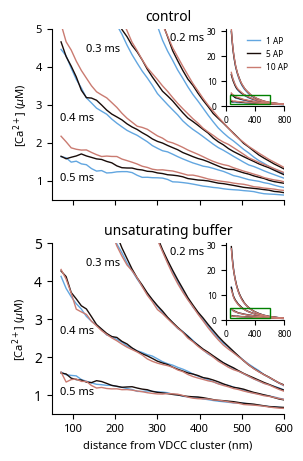

In [22]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'unsaturating buffer': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(len(simtypes),1, figsize=(3,5), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.25)
ins_ax = [ax.inset_axes([.75, .55, .25, .45]) for ax in axs]

cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

to_nm = 1200 # convert um to nm
tpoint_x = [330, 130, 70, 70]
tpoint_y = [4.7, 4.4, 2.6, 1.0]
for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        label = f'{APs[k]} AP'
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], linewidth=1, label=label)
            ins_ax[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], linewidth=1, label=label)
            label = None
            if not k:
                axs[i].text(tpoint_x[j], tpoint_y[j], f'{(tpoint+200)/1000:.1f} ms', fontsize=textfs)
                # axs[i].text(bins[26]*to_nm-60, density[25]-0.2, f'{(tpoint+200)/1000:.1f} ms', fontsize=textfs)
    axs[i].set_title(key, fontsize=titlefs)
    axs[i].set_ylabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=labelfs)

    ## make rectangle for zoomed in region
    rect = mpl.patches.Rectangle((50,0.5), 550, 4, linewidth=1, edgecolor='green', 
                                 facecolor='none', zorder=2)
    ins_ax[i].add_patch(rect)

axs[1].set_xlabel('distance from VDCC cluster (nm)', fontsize=labelfs)

# axs[1].spines["left"].set_visible(False)
axs[0].legend(frameon=False, fontsize=legfs, loc='upper right', handlelength=1.5, bbox_to_anchor=(1.05, 1))
# axs[1].tick_params(axis='y', size=0)
axs[1].tick_params(axis='x', labelsize=tickfs)
axs[0].tick_params(axis='both', labelsize=tickfs)

for ax in axs.ravel():
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(50, 600)
    ax.set_ylim(0.5,5)
    ax.set_yticks([1,2,3,4,5])

for ax in ins_ax:
    # ax.set_ylabel(r'[Ca] ($\mu$M)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 800)
    ax.set_ylim(0,31)
    ax.set_xticks([0, 400, 800])
    ax.set_yticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=tickfs-2)

fig.savefig(os.path.join(figPath, 'ca_domain.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

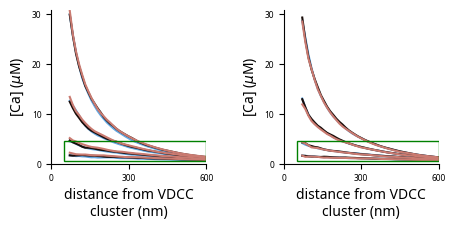

In [5]:
bins = np.arange(0,0.81,0.01)
stpoints = [2600, 82600, 182600]
tpoints = range(0, 301, 100)
APs = [1,5,10]
simtypes = {'control': 'control', 'const buffer conc.': 'const_buffer'}#, 'no_buffer']

fig, axs = plt.subplots(1,len(simtypes), figsize=(5,2), sharex=True)
fig.subplots_adjust(wspace=0.5)
cmap = mpl.colormaps['berlin'] # 'viridis', 'managua', 'berlin'
lcolors = cmap(np.linspace(0.1, 0.9, len(stpoints)))

for i,(key,simtype) in enumerate(simtypes.items()):
    for k,start in enumerate(stpoints):
        for j,tpoint in enumerate(tpoints):
            bins, density = get_conc_along_radius(simtype, start+tpoint, bins=bins)
            density = sp.signal.savgol_filter(density, 7, 3)
            axs[i].plot(bins[6:]*to_nm, density[5:], color=lcolors[k], label=label)

    axs[i].set_xlabel('distance from VDCC\ncluster (nm)')

    ## make rectangle for zoomed in region
    rect = mpl.patches.Rectangle((50,0.5), 550, 4, linewidth=1, edgecolor='green', 
                                 facecolor='none', zorder=2)
    axs[i].add_patch(rect)

for ax in axs.ravel():
    ax.set_ylabel(r'[Ca] ($\mu$M)')
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 600)
    ax.set_ylim(0,31)
    ax.set_xticks([0, 300, 600])
    ax.set_yticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=tickfs-2)

fig.savefig(os.path.join(figPath, 'ca_domain_inset.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

### Calcium overlap

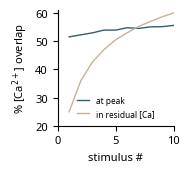

In [89]:
design = 'nVDCC_9_dVAZ_220_nAZ_31_RRP_15_ISI_20_nAP_10'
 
avg_peak_overlap, avg_basal_overlap = get_ca_overlap(design)

y_data = {
    'avg_peak_overlap': avg_peak_overlap, 
    'avg_basal_overlap': avg_basal_overlap
}

keys = ['avg_peak_overlap', 'avg_basal_overlap']

title_text = {'avg_peak_overlap': 'at peak',
              'avg_basal_overlap': 'in residual [Ca]'}

fig, ax = plt.subplots(1, sharex=True, figsize=(1.5,1.5))

for i, key in enumerate(keys):
    x = list(range(1,11))
    y = y_data[key]
    ax.plot(x, np.array(y)*100, linewidth=1, label=title_text[key], color=cpall[i+18])

ax.set_xlim(0.8,10.1)
ax.set_xlabel('stimulus #', fontsize=labelfs)
ax.set_ylabel('% [Ca$^{2+}$] overlap', fontsize=labelfs)
ax.spines[['right', 'top']].set_visible(False)
# ax.set_xticks(range(1,11), [1]+['']*8+[10])
ax.tick_params(axis='both', labelsize=tickfs)
    
ax.legend(frameon=False, handlelength=1.5, fontsize=legfs, loc='lower left', bbox_to_anchor=(0.1, 0.0))
ax.set_xlim(0,10)
ax.set_ylim(20,61)

plt.show()
fig.savefig(os.path.join(figPath, 'ca_overlap.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

### Calcium Signal

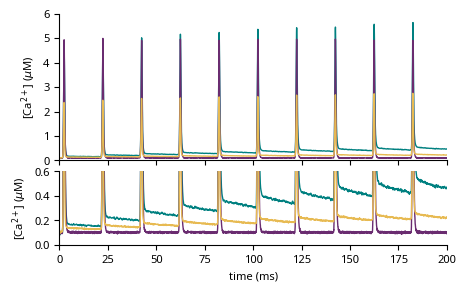

In [79]:
nAZ = int(getSimInfo(design, 'nAZ'))
_design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]

## control
data_cont = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'),
                    usecols=range(nAZ+1), sep='\t')
ca_cont = data_cont.iloc[:, 1:nAZ+1].mean(axis=1)

## unsaturating buffer
data_unsat = pd.read_csv(os.path.join(dataPath, 'control_unsatBuffer', design, 'CaConc.dat'),
                    usecols=range(nAZ+1), sep='\t')
ca_unsat = data_unsat.iloc[:, 1:nAZ+1].mean(axis=1)

## no cross-talk
data_cross = pd.read_csv(os.path.join(dataPath, 'control_eachCa', _design, 'CaConc.dat'), sep='\t')
ca_cross = data_cross.iloc[:, 2::4].mean(axis=1) + data_cross.iloc[:, 3::4].mean(axis=1)

fig, axs = plt.subplots(2, sharex=True, figsize=(5,3), gridspec_kw = {'height_ratios':[2,1]})
fig.subplots_adjust(hspace=0.1)

axs[0].plot(data_cont.iloc[:,0]*1000, ca_cont,   color=cpall[12], linewidth=1, label='control')
axs[0].plot(data_unsat.iloc[:,0]*1000, ca_unsat, color=cpall[14], linewidth=1, label='unsaturating buffer')
axs[0].plot(data_cross.iloc[:,0]*1000, ca_cross, color=cpall[13], linewidth=1, label='without cross-talk')

axs[1].plot(data_cont.iloc[:,0]*1000, ca_cont  , color=cpall[12], linewidth=1, label='control')
axs[1].plot(data_unsat.iloc[:,0]*1000, ca_unsat, color=cpall[14], linewidth=1, label='unsaturating buffer')
axs[1].plot(data_cross.iloc[:,0]*1000, ca_cross, color=cpall[13], linewidth=1, label='without cross-talk')

# axs[0].legend(frameon=False, fontsize=legfs)
axs[0].set_ylim(0,6)
axs[1].set_ylim(0,0.6)
axs[1].set_xlabel('time (ms)', fontsize=labelfs)

for ax in axs.ravel():
    ax.set_ylabel(r'[Ca$^{2+}$] ($\mu$M)', fontsize=labelfs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 200)
    # ax.set_ylim(0,31)
    # ax.set_xticks([0, 300, 600])
    # ax.set_yticks([0, 10, 20, 30])
    ax.tick_params(axis='both', labelsize=tickfs)

fig.savefig(os.path.join(figPath, 'ca_signal.svg'), dpi=300,
            bbox_inches='tight', transparent=True)
plt.show()

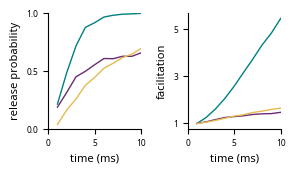

In [82]:
RRP = int(getSimInfo(design, 'RRP'))

## control
data_cont = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                        usecols=['Pr', 'Rel'], sep='\t')
pr_cont = data_cont['Pr']
facil_cont = data_cont['Rel']*data_cont['Pr'][0]/data_cont['Pr']/data_cont['Rel'][0]

## unsaturating buffer
data_unsat = pd.read_csv(os.path.join(dataPath, 'control_unsatBuffer', design, 'result.dat'),
                         usecols=['Pr', 'Rel'], sep='\t')
pr_unsat = data_unsat['Pr']
facil_unsat = data_unsat['Rel']*data_unsat['Pr'][0]/data_unsat['Pr']/data_unsat['Rel'][0]

## no cross-talk
data_cross = pd.read_csv(os.path.join(dataPath, 'control_eachCa', _design, f'sresult_RRP_{RRP}.dat'),
                         usecols=['Pr', 'Rel'], sep='\t')
pr_cross = data_cross['Pr']
facil_cross = data_cross['Rel']*data_cross['Pr'][0]/data_cross['Pr']/data_cross['Rel'][0]

fig, axs = plt.subplots(1,2, sharex=True, figsize=(3,1.5))
fig.subplots_adjust(wspace=0.5)

x = list(range(1,11))
axs[0].plot(x, pr_cont, linewidth=1, color=cpall[12], label='control')
axs[0].plot(x, pr_unsat, linewidth=1, color=cpall[14], label='unsaturating buffer')
axs[0].plot(x, pr_cross, linewidth=1, color=cpall[13], label='without cross-talk')
axs[1].plot(x, facil_cont, linewidth=1, color=cpall[12], label='control')
axs[1].plot(x, facil_unsat, linewidth=1, color=cpall[14], label='unsaturating buffer')
axs[1].plot(x, facil_cross, linewidth=1, color=cpall[13], label='without cross-talk')

axs[0].set_ylim(0,1)
axs[0].set_ylabel(r'release probability', fontsize=labelfs)
axs[0].set_yticks([0,0.5,1])

# axs[0].legend(frameon=False, fontsize=legfs)
# axs[1].set_ylim(1,6)
axs[1].set_ylabel(r'facilitation', fontsize=labelfs)
axs[1].set_yticks([1,3,5])

for ax in axs.ravel():
    ax.set_xlabel('time (ms)', fontsize=labelfs)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, 10)
    ax.set_xticks([0,5,10])
    ax.tick_params(axis='both', labelsize=tickfs-2)

plt.show()
fig.savefig(os.path.join(figPath, 'facilitation.svg'), dpi=300, 
            bbox_inches='tight', transparent=True)

### synaptotagmin

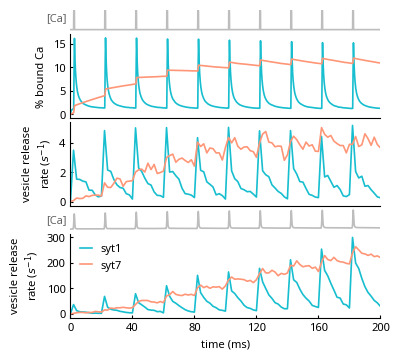

In [68]:
lw = 1.2
tscale = 1e3
f, ax = plt.subplots(5, sharex=True, figsize=(4,4), gridspec_kw={'height_ratios':[1,4,4,1,4]})
f.subplots_adjust(wspace=0.0, hspace=0.06)
for axis in ax:
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'x', which=u'both', length=0, direction='in', labelsize=tickfs)
    axis.tick_params(axis=u'y', which=u'both', length=2, direction='in', labelsize=tickfs)

resCa = 0.4

### Ca Plot
dart = f'resCa_{resCa}_RRP_10'
dreal = design #'nVDCC_9_dVDCC_140_nAZ_19_RRP_10_ISI_20_nAP_10'
inf = os.path.join(resultPath, 'control_eachCa', dart, 'CaConc.dat')
CaData = np.genfromtxt(inf, unpack=True)
ax[0].plot(CaData[0]*tscale, CaData[1], lw=lw, color=cpall[-3])
ax[0].set_xlim(0, 200)
ax[0].text(-16, 4, '[Ca]', fontsize=textfs, color=cpall[-4])
ax[0].spines["left"].set_visible(False)
ax[0].axes.yaxis.set_visible(False)
ax[0].spines["bottom"].set_visible(False)


### AZ plot
inf = os.path.join(resultPath, 'control_eachCa', dart, 'AZ.dat')
azData = np.genfromtxt(inf, unpack=True)
#print(azData.shape)

# syt1
azsyncf = zip([2,8,14,3,9,15,4,10,16,5,11,17,6,12,18], [1,1,1,2,2,2,3,3,3,4,4,4,5,5,5])
azcasync = np.sum(np.array([azData[i]*j for i,j in azsyncf]), axis=0)

# syt7
azasyncf = zip(range(7,19), [1]*6+[2]*6)
azcaasync = np.sum(np.array([azData[i]*j for i,j in azasyncf]), axis=0)

ax[1].plot(azData[0]*tscale, azcasync/(5*10)*100, lw=lw, color=cppaired[1], label='syt1')
ax[1].plot(azData[0]*tscale, azcaasync/(2*10)*100, lw=lw, color=cppaired[3], label='syt7')
ax[1].set_ylabel('% bound Ca', fontsize=labelfs)
ax[1].set_yticks(range(0,20,5))
ax[1].set_xlim(0,200)

# vesicle release rate
inf = os.path.join(resultPath, 'control_eachCa', dart, 'vesData.dat')
with open(inf, "rb") as infile:
    vesData = pk.load(infile)
    
seeds = len(vesData['AZ']['sync'])

svt = np.concatenate(vesData['AZ']['sync'])
avt = np.concatenate(vesData['AZ']['async'])

bindt = 0.002
bins = np.arange(0, 0.210, bindt)

# Synchronous vesicle release rate
sn, _ = np.histogram(svt, bins)#, rwidth=0.9, color=cpallb[i])
svrate = sn/(seeds*bindt)
# Asynchronous vesicle release rate
an, _ = np.histogram(avt, bins)#, rwidth=0.9, color=cpallb[i])
avrate = an/(seeds*bindt)

vratet = np.array([a-bindt for a in bins[1:]])

ax[2].plot(vratet*tscale, svrate, lw=lw, color=cppaired[1], label='syt1')
ax[2].plot(vratet*tscale, avrate, lw=lw, color=cppaired[3], label='syt7')
ax[2].set_xlim(0,200)
ax[2].set_yticks([0, 2, 4])
ax[2].set_ylabel('vesicle release\nrate ($s^{-1}$)', fontsize=labelfs)

### Ca data
data_cont = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'),
                        usecols=range(nAZ+1), sep='\t')
cadata = data_cont.iloc[:, 1:nAZ+1].mean(axis=1)

ax[3].plot(data_cont.iloc[:,0]*tscale, cadata, lw=lw, color=cpall[-3])
ax[3].set_xlim(0, 200)
ax[3].text(-16, 2, '[Ca]', fontsize=textfs, color=cpall[-4])
ax[3].spines["left"].set_visible(False)
ax[3].axes.yaxis.set_visible(False)
ax[3].spines["bottom"].set_visible(False)


# vesicle release rate
inf = os.path.join(resultPath, 'control_eachCa', 
                   'archive/nVDCC_9_dVAZ_200_nAZ_29_RRP_15_ISI_20_nAP_10', 'avesData.dat')
with open(inf, "rb") as infile:
    vesData = pk.load(infile)

seeds = len(vesData['AZ1']['sync'])
#print(seeds)

df = pd.json_normalize(vesData, sep='_')
df = df.to_dict(orient='records')[0]

emptyKeys = []
for k,v in df.items():
    if all([not a for a in v]):
        emptyKeys.append(k)

for e in emptyKeys:
    df.pop(e)

ks = df.keys()
asyncRel = []
syncRel = []
for k in list(ks)[:]:
    if '_async' in k:
        asyncRel.append(np.concatenate(list(df[k])))
    if '_sync' in k:
        syncRel.append(np.concatenate(list(df[k])))
        
avt = np.concatenate(asyncRel)
svt = np.concatenate(syncRel)

bindt = 0.002
bins = np.arange(0, 0.210, bindt)

# Synchronous vesicle release rate
sn, _ = np.histogram(svt, bins)#, rwidth=0.9, color=cpallb[i])
svrate = sn/(seeds*bindt)
# Asynchronous vesicle release rate
an, _ = np.histogram(avt, bins)#, rwidth=0.9, color=cpallb[i])
avrate = an/(seeds*bindt)

vratet = np.array([a-bindt for a in bins[1:]])

ax[4].plot(vratet*tscale, svrate, lw=lw, color=cppaired[1], label='syt1')
ax[4].plot(vratet*tscale, avrate, lw=lw, color=cppaired[3], label='syt7')
ax[4].set_xlim(0,200)
ax[4].set_yticks(range(0,400,100))
ax[4].set_ylabel('vesicle release\nrate ($s^{-1}$)', fontsize=labelfs)
ax[4].legend(frameon=False, loc='upper left', handlelength=1, fontsize=tickfs)#,
             #bbox_to_anchor=(0.96, 0.96, 0.1, 0.1))

#ax[1].text(-15, 4.1, 'g', fontsize=12)
#ax[2].text(-15, 7.2, 'h', fontsize=12)
ax[-1].tick_params(axis=u'x', which=u'both', length=2, direction='in', labelsize=labelfs)
ax[-1].set_xticks(range(0, 201, 40))
ax[-1].set_xlabel('time (ms)', fontsize=labelfs)

plt.savefig(os.path.join(figPath, f'vesRelArt_{resCa}.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### Vesicle release rate

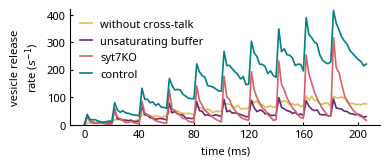

In [80]:
lw = 1.2
tscale = 1e3
f, ax = plt.subplots(1, figsize=(4,1.5))
f.subplots_adjust(wspace=0.0, hspace=0.06)

def get_vrel_rate(inf):
    with open(inf, "rb") as infile:
        vesData = pk.load(infile)

    seeds = len(vesData['AZ1']['sync'])
    #print(seeds)

    df = pd.json_normalize(vesData, sep='_')
    df = df.to_dict(orient='records')[0]

    emptyKeys = []
    for k,v in df.items():
        if all([not a for a in v]):
            emptyKeys.append(k)

    for e in emptyKeys:
        df.pop(e)

    ks = df.keys()

    rel = []
    for k in list(ks)[:]:
        if 'sync' in k:
            rel.append(np.concatenate(list(df[k])))
    rel = np.concatenate(rel)

    bindt = 0.002
    bins = np.arange(0, 0.210, bindt)

    ## Total vesicle release rate
    n, _ = np.histogram(rel, bins)#, rwidth=0.9, color=cpallb[i])
    vrate = n/(seeds*bindt)

    vratet = np.array([a-bindt for a in bins[1:]])
    return vratet, vrate

### without cross-talk
inf = os.path.join(resultPath, 'control_eachCa', 
                   'archive/nVDCC_7_dVAZ_160_nAZ_19_RRP_40_ISI_20_nAP_10', 'svesData.dat')
                #    'archive/nVDCC_9_dVAZ_200_nAZ_29_RRP_15_ISI_20_nAP_10', 'svesData.dat')
vratet, svrate = get_vrel_rate(inf)
ax.plot(vratet*tscale, svrate, lw=lw, color=cpall[13], label='without cross-talk')

### unsaturating buffer
inf = os.path.join(resultPath, 'control_unsatBuffer', 
                   'archive/nVDCC_9_dVAZ_200_nAZ_29_RRP_15_ISI_20_nAP_10', 'vesData.dat')
vratet, uvrate = get_vrel_rate(inf)
ax.plot(vratet*tscale, uvrate, lw=lw, color=cpall[14], label='unsaturating buffer')

### syt7KO
inf = os.path.join(resultPath, 'syt7KO', 
                   'archive/nVDCC_9_dVAZ_200_nAZ_29_RRP_15_ISI_20_nAP_10', 'vesData.dat')
vratet, kvrate = get_vrel_rate(inf)
ax.plot(vratet*tscale, kvrate, lw=lw, color=cpall[11], label='syt7KO')

### Control
inf = os.path.join(resultPath, 'control_eachCa', 
                   'archive/nVDCC_7_dVAZ_160_nAZ_19_RRP_40_ISI_20_nAP_10', 'avesData.dat')
                #    'archive/nVDCC_9_dVAZ_200_nAZ_29_RRP_15_ISI_20_nAP_10', 'avesData.dat')
vratet, tvrate = get_vrel_rate(inf)
ax.plot(vratet*tscale, tvrate, lw=lw, color=cpall[12], label='control')


ax.legend(frameon=False, loc='upper left', handlelength=1, fontsize=legfs+2)

ax.set_ylim(0, 420)
ax.set_xticks(range(0, 201, 40))
# ax.set_yticks(range(0,600,100))

ax.set_xlabel('time (ms)', fontsize=labelfs)
ax.set_ylabel('vesicle release\nrate ($s^{-1}$)', fontsize=labelfs)


ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis=u'x', which=u'both', length=2, direction='in', labelsize=tickfs)
ax.tick_params(axis=u'y', which=u'both', length=2, direction='in', labelsize=tickfs)

plt.savefig(os.path.join(figPath, f'vesRel.svg'), 
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()